In [1]:
# Model 2: Random Forest
import pandas as pd
import numpy as np

# Load the same feature-engineered, preprocessed data used for Model 1
X_train = pd.read_csv("../data/processed_fe/X_train_balanced.csv")
y_train = pd.read_csv("../data/processed_fe/y_train_balanced.csv").values.ravel()
X_test = pd.read_csv("../data/processed_fe/X_test.csv")
y_test = pd.read_csv("../data/processed_fe/y_test.csv").values.ravel()

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Test fraud cases:", int(y_test.sum()))

Training set: (454902, 31)
Test set: (56962, 31)
Test fraud cases: 98


In [2]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random forest model
# n_estimators=100 -> build 100 decision trees and combine their votes
# max_depth=20 -> limit how deep each tree grows, to help prevent overfitting
# n_jobs= -1 -> use all CPU cores to train faster
# random_state=42 -> reproducible results
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

# Train the model on the balanced training data
model_rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [3]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Predict on the untouched test set
y_pred = model_rf.predict(X_test)
y_pred_proba = model_rf.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

# Key metrics for imbalanced data
print("ROC-AUC score:", round(roc_auc_score(y_test, y_pred_proba), 4))
print("PR-AUC score:", round(average_precision_score(y_test, y_pred_proba), 4))

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.75      0.84      0.79        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC score: 0.9837
PR-AUC score: 0.8639


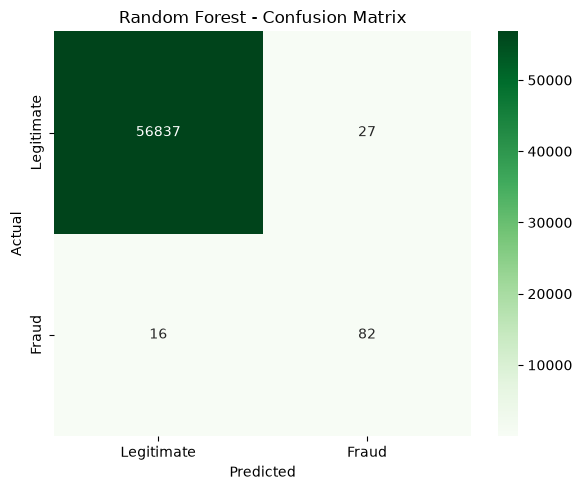

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Legitimate", "Fraud"],
            yticklabels=["Legitimate", "Fraud"])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
